# 03. Evaluation by skin tone

Computes every table and figure in the manuscript from the saved predictions and cohort files. It needs no GPU and no image data, and runs in a few minutes on a laptop.

**Inputs:** `results/predictions/`, `results/cohorts/`, `results/model/model_run_config.json`, `results/logs/model_development_kaggle_log.txt`.
**Outputs:** `results/tables/` and `results/figures/`.

Analysis plan, fixed before model training:

- **Primary comparison:** DDI Fitzpatrick I–II versus III–VI. All DDI lesions were biopsied, and comparing within one dataset keeps imaging modality and source constant. III–IV and V–VI are also reported separately.
- **PAD-UFES-20:** types I–III versus IV–VI, analysed separately and never pooled with DDI. Lesions were biopsied when clinically suspicious, so its calibration describes a biopsied sample and is not a fair test of the model.
- **Sensitivity analysis:** Fitzpatrick17k, types I–III versus IV–VI. Labels are from dermatology atlases and are not biopsy-confirmed.
- Observed-to-expected ratio and net benefit with 95% bootstrap intervals in every stratum; calibration slope and decile calibration plots only where a stratum has at least 50 events. Types V–VI are descriptive.

## 1. Setup

In [1]:
import json
import re
import sys
from decimal import Decimal, ROUND_HALF_UP
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "dermcal").is_dir())
sys.path.insert(0, str(REPO / "src"))
from dermcal import cohort, metrics as M

RES = REPO / "results"
TAB = RES / "tables"; TAB.mkdir(exist_ok=True)
FIG = RES / "figures"; FIG.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9})


def r2(x):
    # round half up, so that figures and tables agree to two decimals
    return str(Decimal(str(x)).quantize(Decimal("0.01"), rounding=ROUND_HALF_UP))


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")

In [2]:
val = pd.read_csv(RES / "predictions" / "predictions_development_heldout.csv")
ext_a = pd.read_csv(RES / "predictions" / "predictions_external_armA.csv")   # biopsy-confirmed
ext_b = pd.read_csv(RES / "predictions" / "predictions_external_armB.csv")   # all confirmation methods
arm_a = pd.read_csv(RES / "cohorts" / "cohort_arm_a_endpoint.csv", low_memory=False)
arm_b = pd.read_csv(RES / "cohorts" / "cohort_arm_b_endpoint.csv", low_memory=False)
run = json.loads((RES / "model" / "model_run_config.json").read_text())
summary = json.loads((RES / "cohorts" / "cohort_summary.json").read_text())

ddi = ext_a[ext_a["source"] == "DDI"]
pad = ext_a[ext_a["source"] == "PAD-UFES-20"]
f17 = ext_b[ext_b["source"] == "Fitzpatrick17k"]

# The DDI research use agreement does not allow its images or labels to be
# redistributed, so the public repository carries no DDI rows. With a copy of
# DDI, notebooks 01 and 02 regenerate them and the DDI results below reappear.
HAS_DDI = len(ddi) > 0
if not HAS_DDI:
    print("No DDI rows: the DDI sections are skipped. See the data section of the README.")

STRATA = {k: v for k, v in {
    "DDI I-II":   ddi[ddi["fst_group"].eq("I-II")] if HAS_DDI else ddi,
    "DDI III-VI": ddi[ddi["fst_group"].isin(["III-IV", "V-VI"])] if HAS_DDI else ddi,
    "DDI III-IV": ddi[ddi["fst_group"].eq("III-IV")] if HAS_DDI else ddi,
    "DDI V-VI":   ddi[ddi["fst_group"].eq("V-VI")] if HAS_DDI else ddi,
    "PAD I-III":  pad[pad["fitzpatrick"].between(1, 3)],
    "PAD IV-VI":  pad[pad["fitzpatrick"].between(4, 6)],
    "F17k I-III": f17[f17["fitzpatrick"].between(1, 3)],
    "F17k IV-VI": f17[f17["fitzpatrick"].between(4, 6)],
    "Held-out":   val,
}.items() if len(v)}
pd.DataFrame({k: {"images": len(d), "events": int(d["label_malignant"].sum())} for k, d in STRATA.items()}).T

,images,events
DDI I-II,201,42
DDI III-VI,407,81
DDI III-IV,232,65
DDI V-VI,175,16
PAD I-III,1281,1055
PAD IV-VI,61,34
F17k I-III,11063,1651
F17k IV-VI,4949,509
Held-out,2820,1254


## 2. Table 1. Cohort characteristics

Development counts are for the histopathology-confirmed cohort before matching to image files. DDI and PAD-UFES-20 come from the histopathology-confirmed cohort; Fitzpatrick17k from the cohort with all confirmation methods.

In [3]:
t1 = pd.concat([cohort.cohort_summary(arm_a),
                cohort.cohort_summary(arm_b[arm_b["source"] == "Fitzpatrick17k"])], ignore_index=True)
t1.to_csv(TAB / "table1_cohort_summary.csv", index=False)
t1

,role,source,modality,n,malignant,benign,prevalence,has_fitzpatrick_%,median_age,female_%
0,development,ISIC2019,dermoscopic,19556,9454,10102,0.4834,0.0,60.0,46.1
1,development,ISIC2020,dermoscopic,1667,584,1083,0.3503,0.0,55.0,41.6
2,development,ISIC2017,dermoscopic,1649,373,1276,0.2262,0.0,NaN,NaN
3,external_test,PAD-UFES-20,clinical,1342,1089,253,0.8115,100.0,64.0,50.1
4,external_test,DDI,clinical,608,123,485,0.2023,100.0,NaN,NaN
5,external_test,Fitzpatrick17k,clinical,16577,2263,14314,0.1365,96.6,NaN,NaN


## 3. Table 2. Discrimination, calibration and net benefit by stratum

95% percentile bootstrap intervals from 2,000 resamples (seed 1234). Net benefit is at a threshold of 0.10 and is compared with biopsying every lesion.

In [4]:
t2 = pd.DataFrame([M.stratum_summary(name, d) for name, d in STRATA.items()])
t2.to_csv(TAB / "table2_performance_by_stratum.csv", index=False)


def ci(est, lo, hi, fmt="{:.2f}"):
    if not np.isfinite(est):
        return "NE"
    return f"{fmt.format(est)} ({fmt.format(lo)} to {fmt.format(hi)})"


shown = pd.DataFrame({
    "Stratum": t2["stratum"], "Images": t2["n"], "Events": t2["events"],
    "Proportion malignant": t2["prev"].round(2),
    "AUC (95% CI)": [ci(*r) for r in t2[["AUC", "AUC_lo", "AUC_hi"]].to_numpy()],
    "O/E (95% CI)": [ci(*r) for r in t2[["OE", "OE_lo", "OE_hi"]].to_numpy()],
    "Calibration slope (95% CI)": [ci(*r) for r in t2[["slope", "slope_lo", "slope_hi"]].to_numpy()],
    "Net benefit (95% CI)": [ci(*r, fmt="{:.3f}") for r in t2[["NB", "NB_lo", "NB_hi"]].to_numpy()],
    "Biopsy all": t2["NB_all"].round(3),
})
shown

,Stratum,Images,Events,Proportion malignant,AUC (95% CI),O/E (95% CI),Calibration slope (95% CI),Net benefit (95% CI),Biopsy all
0,DDI I-II,201,42,0.21,0.62 (0.51 to 0.71),1.17 (0.86 to 1.49),NE,0.098 (0.045 to 0.152),0.121
1,DDI III-VI,407,81,0.20,0.70 (0.63 to 0.76),0.99 (0.81 to 1.18),0.63 (0.43 to 0.87),0.108 (0.069 to 0.145),0.110
2,DDI III-IV,232,65,0.28,0.72 (0.65 to 0.79),1.43 (1.17 to 1.73),0.77 (0.52 to 1.11),0.183 (0.126 to 0.247),0.200
3,DDI V-VI,175,16,0.09,0.69 (0.54 to 0.84),0.44 (0.24 to 0.65),NE,0.008 (-0.032 to 0.057),-0.010
4,PAD I-III,1281,1055,0.82,0.62 (0.58 to 0.66),1.73 (1.67 to 1.79),0.38 (0.26 to 0.50),0.782 (0.758 to 0.805),0.804
5,PAD IV-VI,61,34,0.56,0.82 (0.70 to 0.91),1.48 (1.20 to 1.79),NE,0.488 (0.353 to 0.618),0.508
6,F17k I-III,11063,1651,0.15,0.57 (0.56 to 0.59),0.69 (0.66 to 0.72),0.28 (0.22 to 0.34),0.051 (0.045 to 0.058),0.055
7,F17k IV-VI,4949,509,0.10,0.57 (0.55 to 0.60),0.48 (0.44 to 0.52),0.26 (0.16 to 0.36),0.009 (0.000 to 0.017),0.003
8,Held-out,2820,1254,0.44,0.86 (0.85 to 0.88),0.97 (0.94 to 1.00),0.99 (0.91 to 1.06),0.393 (0.372 to 0.412),0.383


Within DDI, the pooled III–VI ratio is close to 1, but the two subgroups lie on opposite sides of it: risk is underestimated in III–IV (O/E above 1) and overestimated in V–VI (O/E below 1). The V–VI estimate rests on 16 events.

## 4. Figure 4. Observed-to-expected ratios

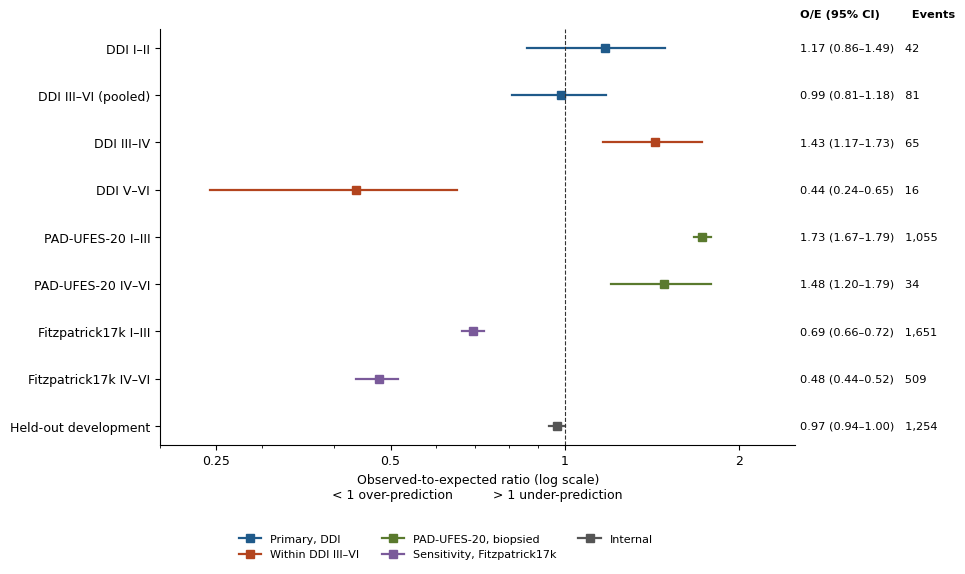

In [5]:
labels = {"DDI I-II": "DDI I–II", "DDI III-VI": "DDI III–VI (pooled)", "DDI III-IV": "DDI III–IV",
          "DDI V-VI": "DDI V–VI", "PAD I-III": "PAD-UFES-20 I–III", "PAD IV-VI": "PAD-UFES-20 IV–VI",
          "F17k I-III": "Fitzpatrick17k I–III", "F17k IV-VI": "Fitzpatrick17k IV–VI",
          "Held-out": "Held-out development"}
group = {"DDI I-II": "Primary, DDI", "DDI III-VI": "Primary, DDI",
         "DDI III-IV": "Within DDI III–VI", "DDI V-VI": "Within DDI III–VI",
         "PAD I-III": "PAD-UFES-20, biopsied", "PAD IV-VI": "PAD-UFES-20, biopsied",
         "F17k I-III": "Sensitivity, Fitzpatrick17k", "F17k IV-VI": "Sensitivity, Fitzpatrick17k",
         "Held-out": "Internal"}
colors = {"Primary, DDI": "#1f5a8a", "Within DDI III–VI": "#b3441e",
          "PAD-UFES-20, biopsied": "#5a7a2e", "Sensitivity, Fitzpatrick17k": "#7a5a9a",
          "Internal": "#555555"}

fig, ax = plt.subplots(figsize=(8.2, 5.4))
y = list(range(len(t2)))[::-1]
for yi, r in zip(y, t2.itertuples(index=False)):
    c = colors[group[r.stratum]]
    ax.plot([r.OE_lo, r.OE_hi], [yi, yi], color=c, lw=1.6)
    ax.plot(r.OE, yi, "s", color=c, ms=6)
    ax.text(2.55, yi, f"{r2(r.OE)} ({r2(r.OE_lo)}–{r2(r.OE_hi)})   {r.events:,}", va="center", fontsize=8.2)
ax.axvline(1, ls="--", color="#333333", lw=0.8)
ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2]); ax.set_xticklabels(["0.25", "0.5", "1", "2"])
ax.set_xlim(0.2, 2.5)
ax.set_yticks(y); ax.set_yticklabels([labels[s] for s in t2["stratum"]])
ax.set_xlabel("Observed-to-expected ratio (log scale)\n< 1 over-prediction          > 1 under-prediction")
ax.text(2.55, len(t2) - 0.35, "O/E (95% CI)        Events", fontsize=8.2, fontweight="bold")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
handles = [plt.Line2D([], [], color=v, marker="s", lw=1.6, label=k) for k, v in colors.items()]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.45, -0.3), ncol=3, frameon=False, fontsize=8)
save(fig, "Figure4_OE_forest")
plt.show()

## 5. Figure 2. Calibration by decile of predicted risk

Only strata with at least 50 events are shown. Bars are 95% Wilson intervals.

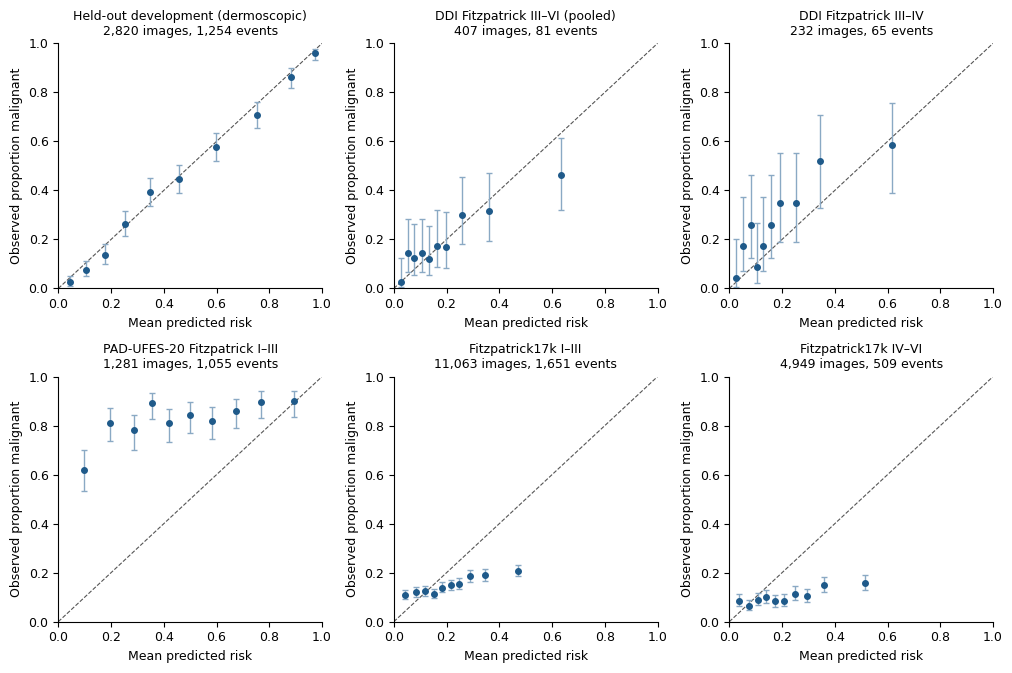

In [6]:
cal = [(t, k) for t, k in [("Held-out development (dermoscopic)", "Held-out"),
                            ("DDI Fitzpatrick III–VI (pooled)", "DDI III-VI"),
                            ("DDI Fitzpatrick III–IV", "DDI III-IV"),
                            ("PAD-UFES-20 Fitzpatrick I–III", "PAD I-III"),
                            ("Fitzpatrick17k I–III", "F17k I-III"),
                            ("Fitzpatrick17k IV–VI", "F17k IV-VI")] if k in STRATA]
fig, axes = plt.subplots(2, 3, figsize=(10.2, 6.8))
for ax in axes.ravel()[len(cal):]:
    ax.axis("off")
for ax, (title, key) in zip(axes.ravel(), cal):
    d = STRATA[key]
    y_, p_ = d["label_malignant"].to_numpy(float), d["risk"].to_numpy(float)
    assert y_.sum() >= M.MIN_EVENTS_SLOPE
    dc = M.decile_calibration(y_, p_)
    ax.plot([0, 1], [0, 1], color="#555555", lw=0.8, ls="--")
    ax.errorbar(dc["mean_predicted"], dc["observed"],
                yerr=[dc["observed"] - dc["observed_lo"], dc["observed_hi"] - dc["observed"]],
                fmt="o", ms=4, color="#1f5a8a", ecolor="#8aa9c4", elinewidth=1, capsize=2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{title}\n{len(d):,} images, {int(y_.sum()):,} events", fontsize=9)
    ax.set_xlabel("Mean predicted risk"); ax.set_ylabel("Observed proportion malignant")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()
save(fig, "Figure2_calibration")
plt.show()

## 6. Figure 3. Decision curves within DDI

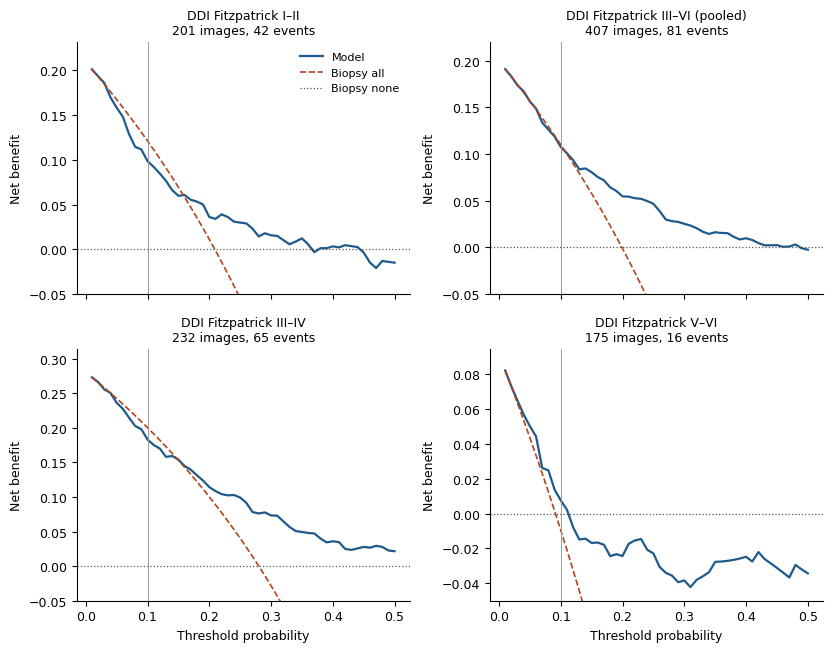

In [7]:
if not HAS_DDI:
    print("Skipped: this repository carries no DDI rows.")
else:
    panels = [("DDI Fitzpatrick I–II", "DDI I-II"), ("DDI Fitzpatrick III–VI (pooled)", "DDI III-VI"),
              ("DDI Fitzpatrick III–IV", "DDI III-IV"), ("DDI Fitzpatrick V–VI", "DDI V-VI")]
    ts = np.round(np.arange(0.01, 0.501, 0.01), 2)
    curves = {}
    fig, axes = plt.subplots(2, 2, figsize=(8.4, 6.6), sharex=True)
    for ax, (title, key) in zip(axes.ravel(), panels):
        d = STRATA[key]
        dc = M.decision_curve(d["label_malignant"], d["risk"], ts)
        curves[key] = dc
        ax.plot(ts, dc["model"], color="#1f5a8a", lw=1.6, label="Model")
        ax.plot(ts, dc["biopsy_all"], color="#b3441e", lw=1.2, ls="--", label="Biopsy all")
        ax.axhline(0, color="#555555", lw=0.9, ls=":", label="Biopsy none")
        ax.axvline(0.10, color="#999999", lw=0.7)
        top = max(dc["model"].max(), dc["biopsy_all"].max(), 0.02)
        ax.set_ylim(-0.05, top * 1.15)
        ax.set_title(f"{title}\n{len(d)} images, {int(d['label_malignant'].sum())} events", fontsize=9)
        ax.set_ylabel("Net benefit")
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    for ax in axes[1]:
        ax.set_xlabel("Threshold probability")
    axes[0, 0].legend(frameon=False, fontsize=8, loc="upper right")
    fig.tight_layout()
    save(fig, "Figure3_decision_curves")
    plt.show()

    pd.concat({k: v for k, v in curves.items()}, names=["stratum"]).reset_index(level=0).to_csv(
        TAB / "decision_curves_ddi.csv", index=False)

In [8]:
if not HAS_DDI:
    print("Skipped: this repository carries no DDI rows.")
else:
    # Thresholds quoted in the Results: the model stays above biopsy-all from the
    # threshold after the last one at which it is at or below it
    for key, dc in curves.items():
        last_not_above = dc.loc[dc["model"] <= dc["biopsy_all"], "threshold"].max()
        first_negative = dc.loc[dc["model"] < 0, "threshold"].min()
        print(f"{key:<11} above biopsy all from {last_not_above + 0.01:.2f}   "
              f"first threshold with negative net benefit: {first_negative:.2f}")

DDI I-II    above biopsy all from 0.16   first threshold with negative net benefit: 0.37
DDI III-VI  above biopsy all from 0.11   first threshold with negative net benefit: 0.49
DDI III-IV  above biopsy all from 0.15   first threshold with negative net benefit: nan
DDI V-VI    above biopsy all from 0.02   first threshold with negative net benefit: 0.12


## 7. Tables 3 and 4. Case-mix and predicted risk within DDI (exploratory)

These analyses were not pre-specified.

In [9]:
if not HAS_DDI:
    print("Skipped: this repository carries no DDI rows.")
else:
    ddi_dx = ddi.merge(arm_a[arm_a["source"] == "DDI"][["image_id", "dx_raw"]], on="image_id", how="left")
    assert ddi_dx["dx_raw"].notna().all()


    def dx_group(d):
        d = str(d).lower()
        if "melanoma" in d:
            return "Melanoma, all subtypes"
        if "basal" in d:
            return "Basal cell carcinoma"
        if "keratoacanthoma" in d:
            return "Keratoacanthoma"
        if "squamous" in d and "situ" in d:
            return "Squamous cell carcinoma in situ"
        if "squamous" in d:
            return "Squamous cell carcinoma, invasive"
        raise ValueError(f"unexpected malignant diagnosis: {d}")


    mal = ddi_dx[ddi_dx["label_malignant"] == 1].copy()
    mal["diagnosis"] = mal["dx_raw"].map(dx_group)
    t3 = pd.crosstab(mal["diagnosis"], mal["fst_group"], margins=True, margins_name="Total")
    t3.to_csv(TAB / "table3_ddi_diagnoses_by_skin_tone.csv")
    t3

In [10]:
if not HAS_DDI:
    print("Skipped: this repository carries no DDI rows.")
else:
    rng = np.random.default_rng(M.SEED)


    def mean_ci(x):
        b = [x[rng.integers(0, len(x), len(x))].mean() for _ in range(M.N_BOOT)]
        return x.mean(), *np.percentile(b, [2.5, 97.5])


    rows = []
    for g in ["I-II", "III-IV", "V-VI"]:
        r = {"group": g, "lesions": int((ddi_dx["fst_group"] == g).sum())}
        for lab, name in [(0, "benign"), (1, "malignant")]:
            x = ddi_dx[(ddi_dx["fst_group"] == g) & (ddi_dx["label_malignant"] == lab)]["risk"].to_numpy()
            m, lo, hi = mean_ci(x)
            r.update({f"{name}_n": len(x), f"{name}_mean": round(m, 3), f"{name}_ci": f"{lo:.3f}-{hi:.3f}"})
        rows.append(r)
    t4 = pd.DataFrame(rows)
    t4.to_csv(TAB / "table4_mean_predicted_risk.csv", index=False)
    t4

In [11]:
if not HAS_DDI:
    print("Skipped: this repository carries no DDI rows.")
else:
    # Melanocytic naevi (DDI label "melanocytic-nevi")
    nv = ddi_dx[ddi_dx["dx_raw"] == "melanocytic-nevi"]
    nv.groupby("fst_group")["risk"].agg(lesions="size", mean_predicted_risk="mean").round(3)

## 8. Development images not used for training

Of the 22,872 histopathology-confirmed development images, 19,506 were found in the Kaggle mirrors (notebook 02). The ISIC 2019 test images are missing from the ISIC 2019 mirror; those that are also ISIC 2018 test images (ISIC_0034524 to ISIC_0036059) were available through the ISIC 2018 mirror.

In [12]:
dev = arm_a[arm_a["role"] == "development"]
display(pd.crosstab(dev["source"], dev["source_split"].fillna("none"), margins=True))

used = run["n_train"] + run["n_val"]
t19 = dev[(dev["source"] == "ISIC2019") & (dev["source_split"] == "test")]
num = t19["image_id"].str.replace("ISIC_", "").astype(int)
in18 = num.between(34524, 36059)
print(f"used for training and held-out   {used:,} of {len(dev):,} ({100 * used / len(dev):.1f}%)")
print(f"not used                         {len(dev) - used:,}")
print(f"ISIC 2019 test images            {len(t19):,}  (of which also ISIC 2018 test: {in18.sum():,})")
print(f"proportion malignant: ISIC 2019 test images outside ISIC 2018 test {t19[~in18]['label_malignant'].mean():.2f}, "
      f"all development images {dev['label_malignant'].mean():.2f}")

source_split,test,train,val,All
source,,,,
ISIC2017,577,962,110,1649
ISIC2019,4152,15404,0,19556
ISIC2020,0,1667,0,1667
All,4729,18033,110,22872


used for training and held-out   19,506 of 22,872 (85.3%)
not used                         3,366
ISIC 2019 test images            4,152  (of which also ISIC 2018 test: 784)
proportion malignant: ISIC 2019 test images outside ISIC 2018 test 0.55, all development images 0.46


## 9. Figure 1. Flow of images

Counts are read from the cohort files, the run configuration and the model development log.

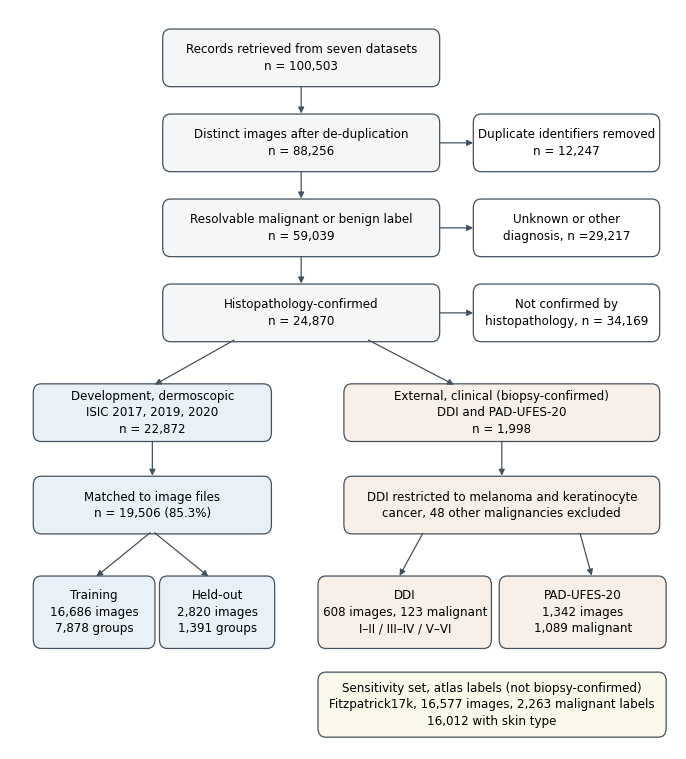

In [13]:
log = (RES / "logs" / "model_development_kaggle_log.txt").read_text(encoding="utf-8")
m = re.search(r"train ([\d,]+) images / ([\d,]+) groups\s+val ([\d,]+) / ([\d,]+)", log)
n_train, g_train, n_val, g_val = (int(x.replace(",", "")) for x in m.groups())
assert (n_train, n_val) == (run["n_train"], run["n_val"])

ddi_c = arm_a[arm_a["source"] == "DDI"]; pad_c = arm_a[arm_a["source"] == "PAD-UFES-20"]
f17_c = arm_b[arm_b["source"] == "Fitzpatrick17k"]
S = summary
n_dev = S["histopathology_confirmed_development"]
fig, ax = plt.subplots(figsize=(8.6, 9.6))
ax.set_xlim(-2, 101); ax.set_ylim(0, 100); ax.axis("off")


def box(x, y, w, h, text, fc="#f4f6f8"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.4,rounding_size=1.2",
                                fc=fc, ec="#44525f", lw=0.9))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=8.6, linespacing=1.35)


def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#44525f", lw=0.9))


box(22, 90, 42, 7, f"Records retrieved from seven datasets\nn = {S['records_downloaded']:,}")
arrow(43, 90, 43, 85.6)
box(22, 78.5, 42, 7, f"Distinct images after de-duplication\nn = {S['distinct_images']:,}")
box(70, 78.5, 28, 7, f"Duplicate identifiers removed\nn = {S['records_downloaded'] - S['distinct_images']:,}", fc="#ffffff")
arrow(64, 82, 70, 82)
arrow(43, 78.5, 43, 74.1)
box(22, 67, 42, 7, f"Resolvable malignant or benign label\nn = {S['with_binary_label']:,}")
box(70, 67, 28, 7, f"Unknown or other\ndiagnosis, n ={S['distinct_images'] - S['with_binary_label']:,}", fc="#ffffff")
arrow(64, 70.5, 70, 70.5)
arrow(43, 67, 43, 62.6)
box(22, 55.5, 42, 7, f"Histopathology-confirmed\nn = {S['histopathology_confirmed']:,}")
box(70, 55.5, 28, 7, f"Not confirmed by\nhistopathology, n = {S['with_binary_label'] - S['histopathology_confirmed']:,}", fc="#ffffff")
arrow(64, 59, 70, 59)
arrow(33, 55.5, 20, 49.1)
arrow(53, 55.5, 67, 49.1)
box(2, 42, 36, 7, f"Development, dermoscopic\nISIC 2017, 2019, 2020\nn = {n_dev:,}", fc="#e8f0f8")
box(50, 42, 48, 7, f"External, clinical (biopsy-confirmed)\nDDI and PAD-UFES-20\nn = {S['histopathology_confirmed_external']:,}", fc="#f8efe8")
arrow(20, 42, 20, 36.6)
box(2, 29.5, 36, 7, f"Matched to image files\nn = {n_train + n_val:,} ({100 * (n_train + n_val) / n_dev:.1f}%)", fc="#e8f0f8")
arrow(20, 29.5, 11, 23.1)
arrow(20, 29.5, 29, 23.1)
box(2, 14, 18, 9, f"Training\n{n_train:,} images\n{g_train:,} groups", fc="#e8f0f8")
box(21.5, 14, 17, 9, f"Held-out\n{n_val:,} images\n{g_val:,} groups", fc="#e8f0f8")
arrow(74, 42, 74, 36.6)
box(50, 29.5, 48, 7, "DDI restricted to melanoma and keratinocyte\n"
    f"cancer, {S['ddi_excluded_other_malignancy']} other malignancies excluded", fc="#f8efe8")
arrow(62, 29.5, 58, 23.1)
arrow(86, 29.5, 88, 23.1)
box(46, 14, 26, 9, (f"DDI\n{len(ddi_c):,} images, {int(ddi_c['label_malignant'].sum())} malignant\nI–II / III–IV / V–VI"
                    if HAS_DDI else "DDI\nrows not redistributed\n(see README)"), fc="#f8efe8")
box(74, 14, 25, 9, f"PAD-UFES-20\n{len(pad_c):,} images\n{int(pad_c['label_malignant'].sum()):,} malignant", fc="#f8efe8")
box(46, 2, 53, 8, "Sensitivity set, atlas labels (not biopsy-confirmed)\n"
    f"Fitzpatrick17k, {len(f17_c):,} images, {int(f17_c['label_malignant'].sum()):,} malignant labels\n"
    f"{int(f17_c['fitzpatrick'].notna().sum()):,} with skin type", fc="#fbf8ec")
save(fig, "Figure1_flow")
plt.show()

## 10. Files written

In [14]:
for p in sorted(TAB.glob("*")) + sorted(FIG.glob("*.png")):
    print(p.relative_to(REPO))

results\tables\decision_curves_ddi.csv
results\tables\table1_cohort_summary.csv
results\tables\table2_performance_by_stratum.csv
results\tables\table3_ddi_diagnoses_by_skin_tone.csv
results\tables\table4_mean_predicted_risk.csv
results\figures\Figure1_flow.png
results\figures\Figure2_calibration.png
results\figures\Figure3_decision_curves.png
results\figures\Figure4_OE_forest.png
